# 🏥 CariSurg MedTech Pathways — Week 0, Tutorial 3
## Basic Data Visualisation with matplotlib
**Mercer General Hospital | Clinical AI & Innovation Unit**

---
> **Day 3 Challenge:** Produce clinically meaningful plots from the cleaned triage dataset.
> Every plot must answer a specific question — not just look nice.

---
### What we will cover today
1. Bar plots for categorical columns
2. Histograms for distributions
3. Scatter plots for two-variable relationships
4. Box plots for outlier identification
5. Labelling, saving, and posting plots

**Day 3 Submission:** A notebook with at least two plots — one histogram and one scatter plot.


## 1. Setup — Load and Clean

**[TUTOR NOTE]**
Rather than repeating the cleaning steps live, run this setup block at the start.
Explain that in a real project, cleaning would live in a separate script (we will do this in Week 8).
For now, we consolidate it here so visualisation is the focus.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Mounted at /content/drive
Drive mounted successfully!
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


## 2. Why Visualise?

**[TUTOR NOTE — 3-minute framing before any code]**

A table of numbers is hard to reason about. A plot reveals patterns instantly.

In clinical data science, visualisation serves three purposes:
1. **Quality check** — does the data look like what we expect?
2. **Pattern discovery** — are there relationships between variables?
3. **Communication** — can a nurse or doctor understand our finding in 10 seconds?

The rule for this programme: **every plot must answer a specific clinical question.**
If you cannot state the question, you should not make the plot.


## 3. Bar Plots — Categorical Columns

**Clinical question: What is the gender breakdown of patients in this dataset?**

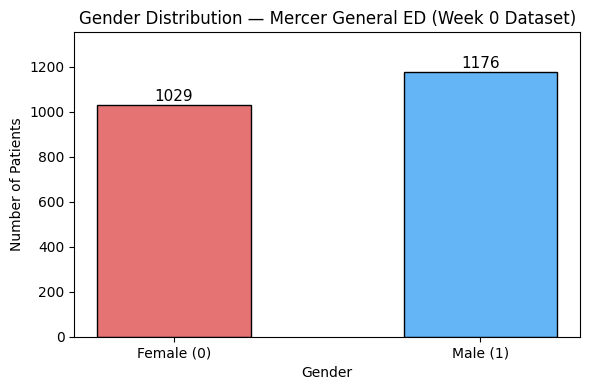

Saved: gender_distribution.png


In [2]:
# Bar plot: Gender distribution
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['Gender'].value_counts().sort_index()
bars = ax.bar(['Female (0)', 'Male (1)'], counts.values,
              color=['#E57373', '#64B5F6'], edgecolor='black', width=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=11)

ax.set_title('Gender Distribution — Mercer General ED (Week 0 Dataset)', fontsize=12)
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: gender_distribution.png")

**[TUTOR NOTE — after running]**
Ask students: "Does the gender split look clinically plausible for an ED population?"
Point out: labels, count annotations, meaningful title, saved file. These are the four things every plot needs.


## 4. Histograms — Distributions

**Clinical question: How are GCS scores distributed across our patients — are most patients alert, or are there many with reduced consciousness?**

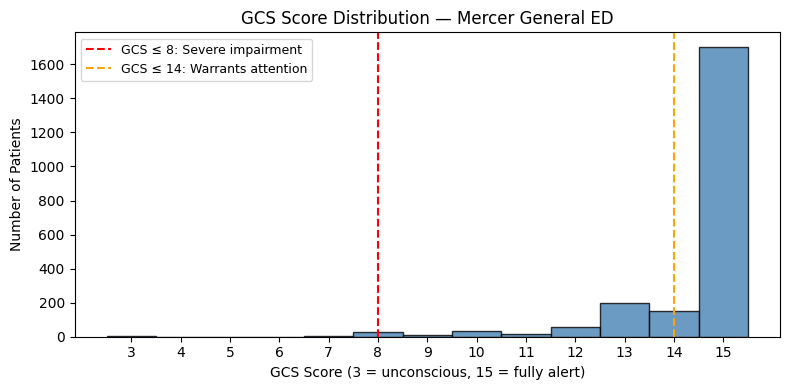

Saved: gcs_histogram.png


In [3]:

# Histogram: GCS distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['GCS'], bins=range(3, 17), edgecolor='black',
        color='steelblue', alpha=0.8, align='left')

# Add a vertical line at the clinical threshold for severe impairment
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.5,
           label='GCS ≤ 8: Severe impairment')
ax.axvline(x=14, color='orange', linestyle='--', linewidth=1.5,
           label='GCS ≤ 14: Warrants attention')

ax.set_title('GCS Score Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('GCS Score (3 = unconscious, 15 = fully alert)')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(3, 16))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('gcs_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: gcs_histogram.png")

**[TUTOR NOTE — key teaching point]**
The vertical reference lines are not decoration — they carry clinical meaning.
GCS ≤ 8 is the threshold for intubation consideration in many protocols.
GCS ≤ 14 triggers additional monitoring at Mercer.

Ask: "What does it tell us that most patients cluster at 15?"
(It suggests most patients arriving at this ED are conscious — consistent with a mixed-acuity emergency department.)


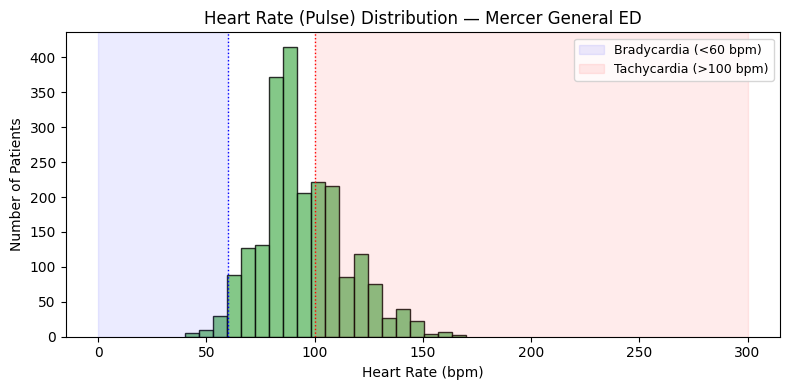

Saved: pulse_histogram.png


In [4]:

# Histogram: Pulse (heart rate) distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['pulse'], bins=20, edgecolor='black', color='#66BB6A', alpha=0.8)

# Clinical reference zones
ax.axvspan(0, 60, alpha=0.08, color='blue', label='Bradycardia (<60 bpm)')
ax.axvspan(100, 300, alpha=0.08, color='red', label='Tachycardia (>100 bpm)')
ax.axvline(x=60, color='blue', linestyle=':', linewidth=1)
ax.axvline(x=100, color='red', linestyle=':', linewidth=1)

ax.set_title('Heart Rate (Pulse) Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Heart Rate (bpm)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pulse_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: pulse_histogram.png")

## 5. Scatter Plots — Two-Variable Relationships

**Clinical question: Is there a relationship between systolic and diastolic blood pressure in these patients? Does it follow what physiology would predict?**

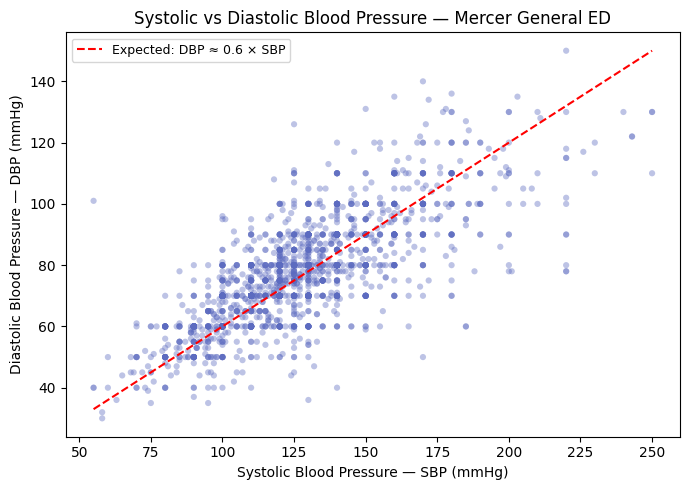

Saved: sbp_vs_dbp.png


In [5]:

# Scatter plot: SBP vs DBP
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['SBP'], df['DBP'],
                     alpha=0.4, s=20, color='#5C6BC0', edgecolors='none')

# Add a trend reference: DBP is typically ~2/3 of SBP
sbp_range = np.linspace(df['SBP'].min(), df['SBP'].max(), 100)
ax.plot(sbp_range, sbp_range * 0.6, color='red', linestyle='--',
        linewidth=1.5, label='Expected: DBP ≈ 0.6 × SBP')

ax.set_title('Systolic vs Diastolic Blood Pressure — Mercer General ED', fontsize=12)
ax.set_xlabel('Systolic Blood Pressure — SBP (mmHg)')
ax.set_ylabel('Diastolic Blood Pressure — DBP (mmHg)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sbp_vs_dbp.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sbp_vs_dbp.png")

**[TUTOR NOTE]**
Ask students: "Do the data points broadly follow the expected ratio?"
Deviations from the trend line can indicate data quality issues or genuinely unusual patients.
This is a quick sanity check — if the scatter looked completely random, we would investigate why.


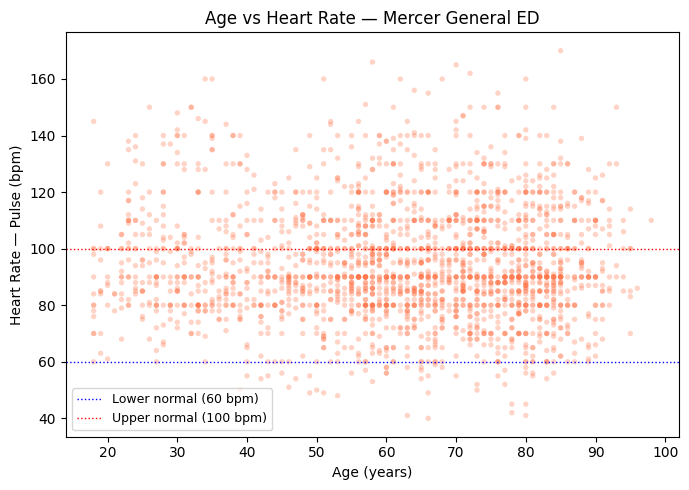

Saved: age_vs_pulse.png


In [6]:

# Scatter plot: Age vs Pulse — does age affect resting heart rate in ED patients?
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['Age'], df['pulse'],
           alpha=0.3, s=15, color='#FF7043', edgecolors='none')

ax.set_title('Age vs Heart Rate — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Heart Rate — Pulse (bpm)')

# Add clinical reference lines
ax.axhline(y=60, color='blue', linestyle=':', linewidth=1, label='Lower normal (60 bpm)')
ax.axhline(y=100, color='red', linestyle=':', linewidth=1, label='Upper normal (100 bpm)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_vs_pulse.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: age_vs_pulse.png")

## 6. Box Plots — Spotting Remaining Outliers

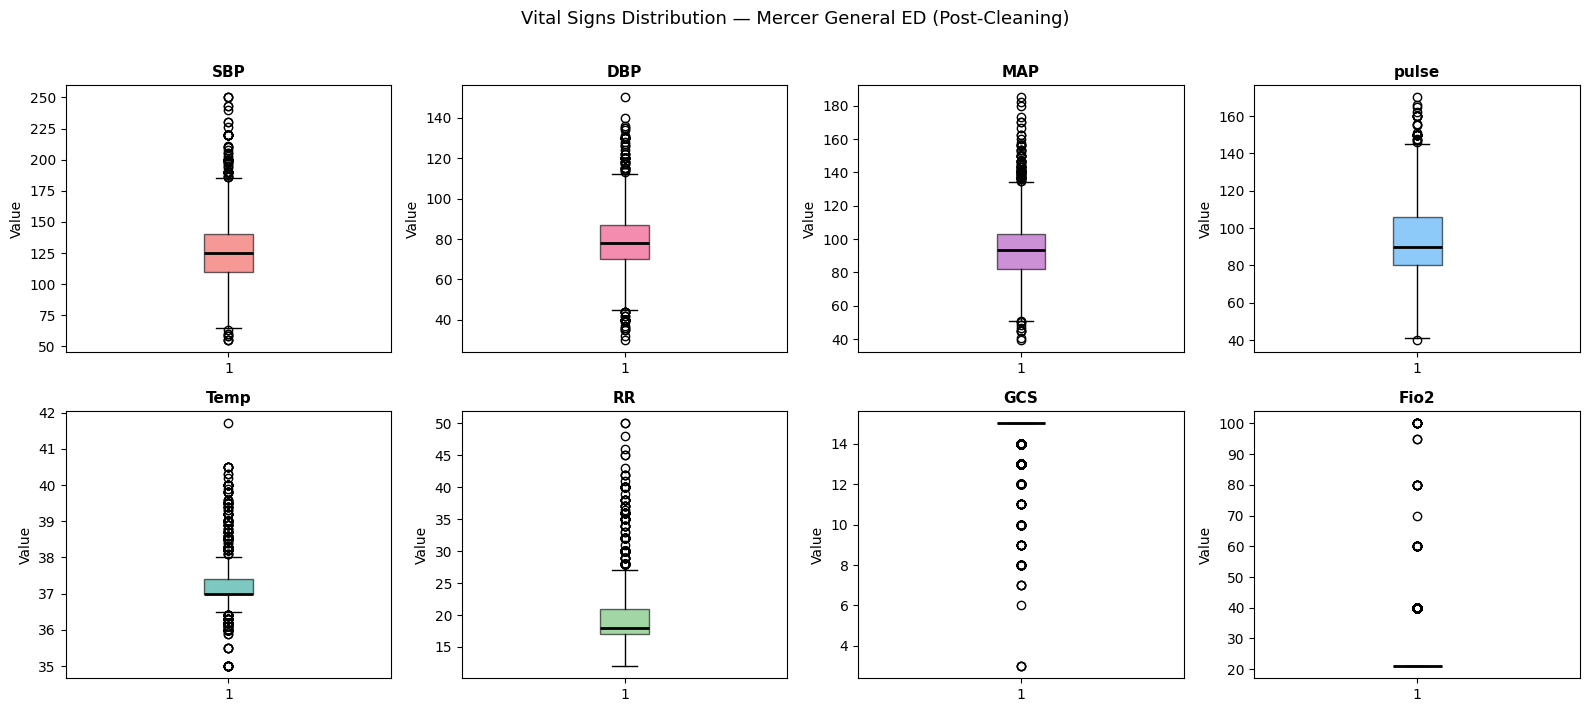

Saved: vitals_boxplots.png


In [7]:

# Box plots for all numeric vitals — side by side for a quick overview
vitals = ['SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'GCS', 'Fio2']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = ['#EF5350','#EC407A','#AB47BC','#42A5F5','#26A69A','#66BB6A','#FFA726','#8D6E63']

for i, (vital, col) in enumerate(zip(vitals, colors)):
    axes[i].boxplot(df[vital].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=col, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(vital, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Vital Signs Distribution — Mercer General ED (Post-Cleaning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vitals_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: vitals_boxplots.png")

**[TUTOR NOTE — ask students]**
"Look at the Fio2 box plot. There are points appearing above the box — are those outliers we should remove?"

Answer: **No.** FiO2 of 100% is clinically valid (ventilated patient). This is why we check the *clinical* meaning of every value before deciding it is an outlier. The data is correct — the distribution just reflects that most patients breathe room air (21%) while a small number need supplemental oxygen.

This is one of the most important lessons in clinical data science: **statistical outlier ≠ erroneous value**.


## 7. Saving and Posting Plots

In [8]:

# Always save plots before posting to Discord or GitHub
# Use dpi=100 for Discord (smaller file), dpi=150 for GitHub README

# Summary: all the plots we created today
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  age_vs_pulse.png                    (113 KB)
  gcs_histogram.png                   (34 KB)
  gender_distribution.png             (23 KB)
  pulse_histogram.png                 (35 KB)
  sbp_vs_dbp.png                      (96 KB)
  vitals_boxplots.png                 (79 KB)


## 8. Student Challenge — Build Your Own Plot

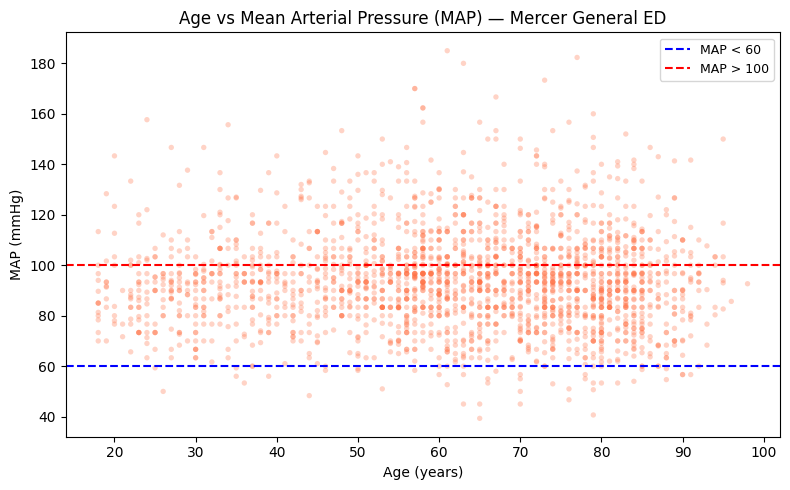

In [12]:
# ── YOUR TURN ────────────────────────────────────────────────
# Pick any two variables from the dataset and create a meaningful plot.
# Before you code, answer these questions in a comment:
#
# 1. What is the clinical question this plot answers?
# 2. What type of plot is appropriate (histogram, scatter, bar, box)?
# 3. What reference lines or annotations would add clinical meaning?

# Your code here:

# Clinical Question: Does MAP increase with age in ED?
# Plot type: Scatter (two continuous numeric values)
# Reference lines: MAP <60 = organ perfusion risk, MAP >100 = hypertensive concern

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['Age'], df['MAP'],
           alpha=0.3, s=15, color='#FF7043', edgecolors='none')

ax.axhline(y=60, color='blue', linestyle='--', linewidth=1.5, label='MAP < 60')
ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='MAP > 100')

ax.set_title('Age vs Mean Arterial Pressure (MAP) — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('MAP (mmHg)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_vs_map.png', dpi=100, bbox_inches='tight')
plt.show()

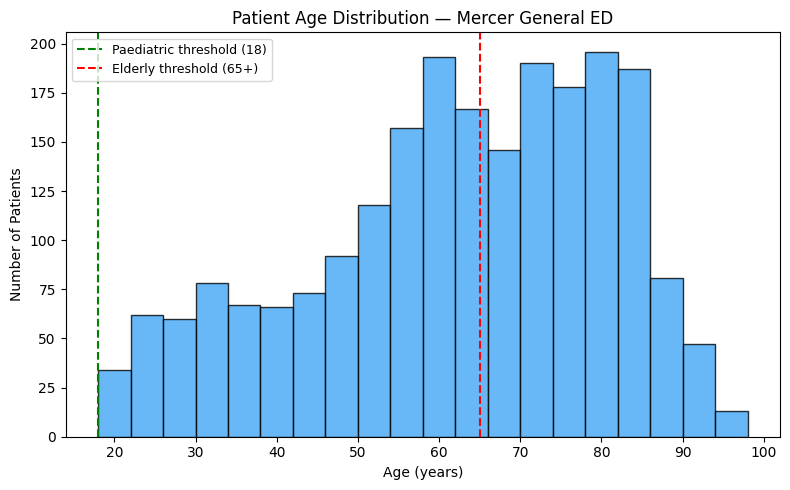

In [16]:

# Clinical Question: What age groups are most frequently to this ED?
# Plot type: Histogram — distribution of one continuous variable (age)
# Reference lines: Paediatric (<18) and elderly (65+)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['Age'], bins=20, edgecolor='black', color='#42A5F5', alpha=0.8)

ax.axvline(x=18, color='green', linestyle='--', linewidth=1.5,
           label='Paediatric threshold (18)')
ax.axvline(x=65, color='red', linestyle='--', linewidth=1.5,
           label='Elderly threshold (65+)')

ax.set_title('Patient Age Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  age_distribution.png                (32 KB)
  age_vs_map.png                      (114 KB)
  age_vs_pulse.png                    (113 KB)
  gcs_histogram.png                   (34 KB)
  gender_distribution.png             (23 KB)
  pulse_histogram.png                 (35 KB)
  sbp_vs_dbp.png                      (96 KB)
  vitals_boxplots.png                 (79 KB)


## 9. Submission Reminder

**Day 3 Deliverable:**
- A notebook containing at least:
  - One histogram (with clinical reference lines labelled)
  - One scatter plot (with axes labelled and a title stating the clinical question)
- Push to your `carisurg-portfolio` repo
- Post your best plot image in `#cohort-2026` on Discord

**Tomorrow (Day 4):** Clinical context write-up — pick one vital sign and explain it in plain language.

---
### Plotting Quick Reference

| Plot type | When to use | Code |
|-----------|-------------|------|
| Bar chart | Categorical column (Gender, triage level) | `plt.bar(x, y)` |
| Histogram | Distribution of one numeric column | `plt.hist(df['col'], bins=N)` |
| Scatter | Relationship between two numeric columns | `plt.scatter(df['x'], df['y'])` |
| Box plot | Distribution + outliers in one column | `plt.boxplot(df['col'])` |

**Every plot needs:** title, x-label, y-label, `plt.savefig(...)`.
